<a href="https://colab.research.google.com/github/madikabhavana-collab/ores5160-2026/blob/main/Mini_health_data_warehouse_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from datetime import datetime

df_raw = pd.read_csv("Medicare_IP_Hospitals_by_Provider_and_Service_2024.csv")
df_raw.head()

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222


In [82]:
try:
    df_test = pd.read_csv("Medicare_IP_Hospitals_by_Provider_and_Service_2024.csv")
    print("File loaded successfully")
except Exception as e:
    print("Error loading file:", e)

File loaded successfully


In [83]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145879 entries, 0 to 145878
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Rndrng_Prvdr_CCN           145879 non-null  int64  
 1   Rndrng_Prvdr_Org_Name      145879 non-null  object 
 2   Rndrng_Prvdr_City          145879 non-null  object 
 3   Rndrng_Prvdr_St            145879 non-null  object 
 4   Rndrng_Prvdr_State_FIPS    145879 non-null  int64  
 5   Rndrng_Prvdr_Zip5          145879 non-null  int64  
 6   Rndrng_Prvdr_State_Abrvtn  145879 non-null  object 
 7   Rndrng_Prvdr_RUCA          145879 non-null  float64
 8   Rndrng_Prvdr_RUCA_Desc     145879 non-null  object 
 9   DRG_Cd                     145879 non-null  int64  
 10  DRG_Desc                   145879 non-null  object 
 11  Tot_Dschrgs                145879 non-null  int64  
 12  Avg_Submtd_Cvrd_Chrg       145879 non-null  float64
 13  Avg_Tot_Pymt_Amt           14

In [84]:
df_raw.isnull().sum()

,0
Rndrng_Prvdr_CCN,0
Rndrng_Prvdr_Org_Name,0
Rndrng_Prvdr_City,0
Rndrng_Prvdr_St,0
Rndrng_Prvdr_State_FIPS,0
Rndrng_Prvdr_Zip5,0
Rndrng_Prvdr_State_Abrvtn,0
Rndrng_Prvdr_RUCA,0
Rndrng_Prvdr_RUCA_Desc,0
DRG_Cd,0


In [85]:
df_raw.head(1000).to_json("cms_sample.json", orient="records", indent=2)

df_json = pd.read_json("cms_sample.json")

df_json.head()

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222


In [86]:
df = df_raw.copy()

df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

df.head()

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222


In [87]:
cols = ['avg_submtd_cvrd_chrg', 'avg_tot_pymt_amt', 'avg_mdcr_pymt_amt']

for col in cols:
    df[col] = df[col].replace(r'[\$,]', '', regex=True).astype(float)

df[cols].head()

,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt
0,738478.636360,103236.272730,91218.181818
1,173562.086960,40220.217391,37634.565217
2,95613.307692,27305.461538,25644.307692
3,182831.409090,31420.954545,23270.863636
4,111318.555560,12183.925926,10532.222222


In [88]:
before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 145879
Rows after: 145879
Duplicates removed: 0


In [89]:
def validate_data(df):
    """Run data quality checks for missingness, logical errors, and outliers."""

    print("Missing Values:\n", df.isnull().sum())

    invalid_discharges = (df["tot_dschrgs"] <= 0).sum()
    print("\nInvalid Discharges (<=0):", invalid_discharges)

    invalid_payments = (df["avg_mdcr_pymt_amt"] > df["avg_tot_pymt_amt"]).sum()
    print("Medicare Payment > Total Payment:", invalid_payments)

    outliers = df[df["avg_submtd_cvrd_chrg"] > 100000]
    print("\nOutliers (charges > 100000):", outliers.shape[0])

validate_data(df)

Missing Values:
 rndrng_prvdr_ccn             0
rndrng_prvdr_org_name        0
rndrng_prvdr_city            0
rndrng_prvdr_st              0
rndrng_prvdr_state_fips      0
rndrng_prvdr_zip5            0
rndrng_prvdr_state_abrvtn    0
rndrng_prvdr_ruca            0
rndrng_prvdr_ruca_desc       0
drg_cd                       0
drg_desc                     0
tot_dschrgs                  0
avg_submtd_cvrd_chrg         0
avg_tot_pymt_amt             0
avg_mdcr_pymt_amt            0
dtype: int64

Invalid Discharges (<=0): 0
Medicare Payment > Total Payment: 0

Outliers (charges > 100000): 41637


In [90]:
conn = sqlite3.connect("hospital.db")

df.to_sql("encounters", conn, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM encounters LIMIT 10", conn)

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222
5,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,39,EXTRACRANIAL PROCEDURES WITHOUT CC/MCC,47,90166.212766,9712.510638,7136.319149
6,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,56,DEGENERATIVE NERVOUS SYSTEM DISORDERS WITH MCC,13,65932.000000,16949.000000,14845.769231
7,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,57,DEGENERATIVE NERVOUS SYSTEM DISORDERS WITHOUT MCC,20,26026.500000,10431.650000,8639.300000
8,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,64,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,74,71396.337838,14841.040541,12331.918919
9,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,65,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,62,40065.596774,8402.016129,6009.790323


In [91]:
pivot = df.pivot_table(
    index='rndrng_prvdr_state_abrvtn',
    values='tot_dschrgs',
    aggfunc='sum'
)

pivot.head()

,tot_dschrgs
rndrng_prvdr_state_abrvtn,
AK,9804
AL,67132
AR,54526
AZ,96271
CA,462315


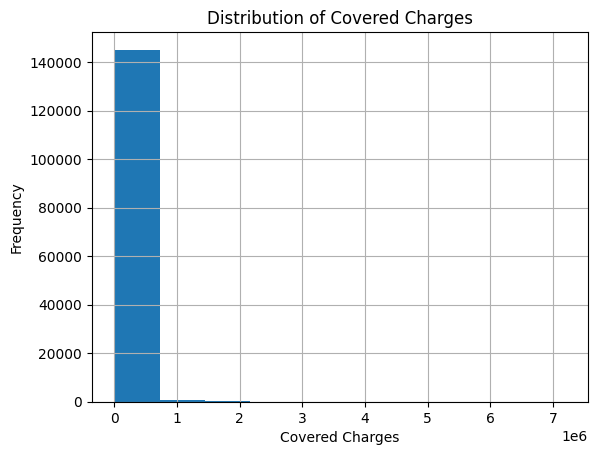

In [92]:
df['avg_submtd_cvrd_chrg'].hist()
plt.title("Distribution of Covered Charges")
plt.xlabel("Covered Charges")
plt.ylabel("Frequency")
plt.show()

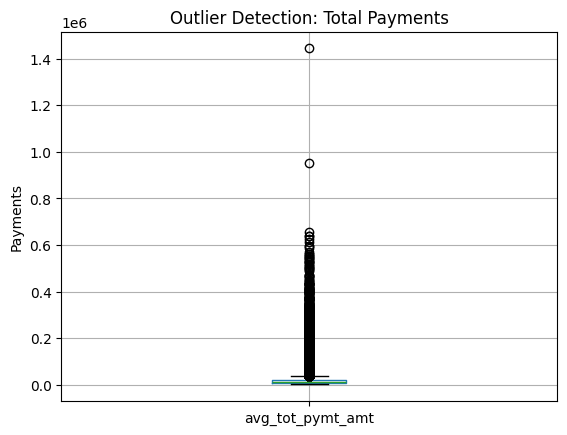

In [93]:
df.boxplot(column='avg_tot_pymt_amt')
plt.title("Outlier Detection: Total Payments")
plt.ylabel("Payments")
plt.show()

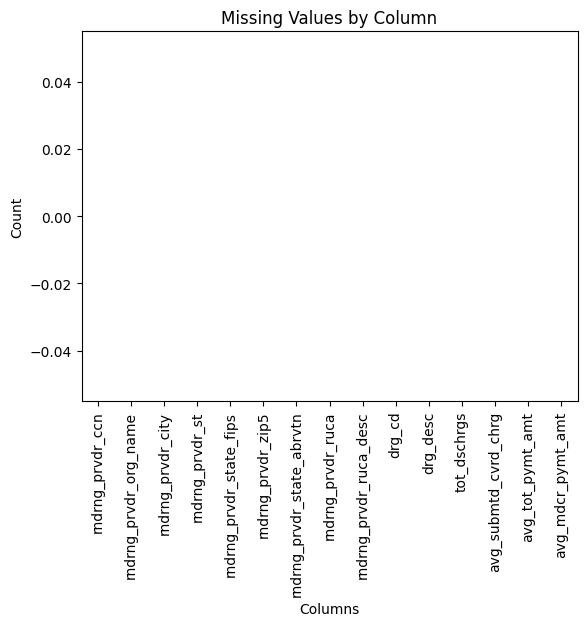

In [94]:
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()

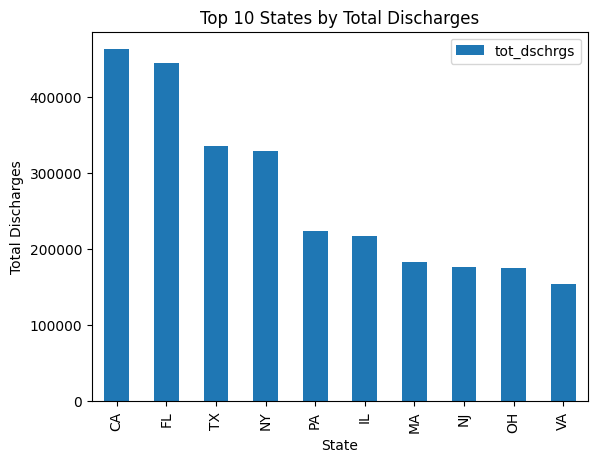

In [95]:
pivot.sort_values('tot_dschrgs', ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 States by Total Discharges")
plt.xlabel("State")
plt.ylabel("Total Discharges")
plt.show()